Amy Suo Rice University

In [ ]:
import numpy as np
import glob
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset
from torch.utils import data
from torchvision import transforms as T
from torchvision import models

torch.manual_seed(0)
np.random.seed(0)

In [ ]:
def show_image_subplot(images : list [np.ndarray], num_rows:int, num_cols :int , titles : list[str] = [], axis:str ='off' , dpi:int = 80, size : tuple[int] = [8, 8]) -> None:
    assert num_rows > 1 or num_cols > 1 ,
    assert len(images) == int(num_rows*num_cols),
    titles = titles + ["No Title" for _ in range(len(images)-len(titles))] if len(titles) < len(images) else titles[:len(images)]
    fig, axs = plt.subplots(nrows=num_rows, ncols=num_cols, dpi=dpi, figsize = size)
    axs_flat = axs.flatten()
    for (_ax, _im, _title) in zip(axs_flat, images, titles):
        _ax.imshow(_im)
        _ax.axis(axis)
        _ax.set_title(_title)
    plt.show()

In [ ]:
!gdown https://drive.google.com/uc?id=1eYYJ26R1S9Ln_ExwHFBqd3rbln9qVdi4&export=download
!unzip -qq cityscapes.zip

Downloading...
From (original): https://drive.google.com/uc?id=1eYYJ26R1S9Ln_ExwHFBqd3rbln9qVdi4
From (redirected): https://drive.google.com/uc?id=1eYYJ26R1S9Ln_ExwHFBqd3rbln9qVdi4&confirm=t&uuid=3e5cbfe4-d36e-4953-8fd8-6536df52290a
To: /content/stylegan2-ada-pytorch/cityscapes.zip
100% 651M/651M [00:03<00:00, 204MB/s]


In [ ]:
class CityScapesDataset(Dataset):
  def __init__(self, images, labels, im_transform, mask_transform):
    self.images = images
    self.labels = labels
    self.im_transform = im_transform
    self.mask_transform = mask_transform

  def __getitem__(self, idx):
    im = Image.open(self.images[idx])
    mask = Image.open(self.labels[idx])
    im = self.im_transform(im)[0:3, ...]

    # add an extra first dimension to mask (needed for transforms), convert
    # to LongTensor b/c values are integers, and apply transforms.
    mask = np.asarray(mask)[None, ...]
    mask = torch.LongTensor(mask)
    mask = self.mask_transform(mask)

    # apply horizontal flip!!!!
    if np.random.rand() > 0.5:
      im = TF.hflip(im)
      mask  = TF.hflip(mask)

    return self.images[idx], im, mask

  def __len__(self):
    return len(self.images)

In [ ]:
batch_size = 16

# image and mask transforms.
im_transform = [T.ToTensor()]
im_transform.append(T.Resize((256, 256), interpolation=T.InterpolationMode.BILINEAR))
im_transform = T.Compose(im_transform)

mask_transform = T.Resize((256, 256), interpolation=T.InterpolationMode.NEAREST)

def get_dataloader(im_path):
  images = sorted(glob.glob(im_path + '/*8bit.jpg'))
  labels = sorted(glob.glob(im_path + '/*labelIds.png'))
  dataset = CityScapesDataset(images, labels, im_transform, mask_transform)
  return data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=1)

# Create dataloaders
train_dataloader = get_dataloader('./cityscapes/train')
val_dataloader = get_dataloader('./cityscapes/val')

In [ ]:
class Segmenter(torch.nn.Module):
    def __init__(self, n_classes):
        super(Segmenter, self).__init__()
        self.encoder = nn.Sequential(
            nn.LazyConv2d(64, 3, padding = 'same'), nn.ReLU(),
            nn.LazyConv2d(64, 3, padding = 'same'), nn.ReLU(),
            nn.MaxPool2d(2, stride = 2),
            nn.LazyConv2d(128, 3, padding = 'same'), nn.ReLU(),
            nn.LazyConv2d(128, 3, padding = 'same'), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.LazyConv2d(256, 3, padding = 'same'), nn.ReLU(),
            nn.LazyConv2d(256, 3, padding = 'same'), nn.ReLU(),
            nn.LazyConv2d(256, 3, padding = 'same'), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.LazyConv2d(512, 3, padding = 'same'), nn.ReLU(),
            nn.LazyConv2d(512, 3, padding = 'same'), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            # upsample w/o convtranspose bc im lazy point finger laugh haha
            nn.LazyConv2d(64, 3, padding = 'same'), nn.ReLU(),
            nn.Upsample(scale_factor = 2, mode = 'nearest'),
            nn.LazyConv2d(64, 3, padding = 'same'), nn.ReLU(),
            nn.Upsample(scale_factor= 2, mode = 'nearest'),
            nn.LazyConv2d(64, 3, padding = 'same'), nn.ReLU(),
            nn.Upsample(scale_factor = 2, mode = 'nearest'),
            nn.LazyConv2d(n_classes, 3, padding = 'same')
        )

    def forward(self, x):
      x = self.encoder(x)
      x= self.decoder(x)
      return x

In [ ]:


# Create model
n_classes = 34
model = Segmenter(n_classes);
model.to('cuda');

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
from tqdm import tqdm
lr = 1e-4
lossn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
num_epochs = 7 # this number can be larger if i had core colab computing units. pls.



for epoch in range(num_epochs):
    curr = 0
    size = len(train_dataloader.dataset)
    model.train()
    for batch, (_, x, y) in tqdm(enumerate(train_dataloader)):
        X, yy = x.to('cuda'), y.to('cuda')
        yy = torch.squeeze(yy)
        optimizer.zero_grad()
        # Compute prediction and loss
        pred = model(X)
        loss = lossn(pred, yy)

        # Backpropagation
        loss.backward()
        optimizer.step()
        curr += loss.item()
    print(f"\n epoch {epoch + 1}: {curr/186:>7f}")


0it [00:00, ?it/s]<ipython-input-3-3b312ff0fea3>:16: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  mask = torch.LongTensor(mask)
186it [02:42,  1.14it/s]


 epoch 1: 0.754975



0it [00:00, ?it/s]<ipython-input-3-3b312ff0fea3>:16: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  mask = torch.LongTensor(mask)
186it [02:42,  1.14it/s]


 epoch 2: 0.678316



0it [00:00, ?it/s]<ipython-input-3-3b312ff0fea3>:16: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  mask = torch.LongTensor(mask)
186it [02:43,  1.14it/s]

...


 epoch 5: 0.581781



0it [00:00, ?it/s]<ipython-input-3-3b312ff0fea3>:16: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  mask = torch.LongTensor(mask)
186it [02:42,  1.14it/s]


 epoch 6: 0.566352



0it [00:00, ?it/s]<ipython-input-3-3b312ff0fea3>:16: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  mask = torch.LongTensor(mask)
186it [02:42,  1.14it/s]


 epoch 7: 0.551564


In [ ]:

model.eval()
size = len(val_dataloader.dataset)
num_batches = len(val_dataloader)
intersection = np.array([1 for i in range(34)], dtype = 'int')
union = np.array([1 for i in range(34)], dtype = 'int')
c = 0
preds = {}
with torch.no_grad():
    for fn, x, y in tqdm(val_dataloader):
      X, yy = x.to('cuda'), y.to('cuda')
      if X.shape[0] != 16:
        break
      pred = model(X).argmax(1)
      result = TF.resize(pred, size=(1024, 2048))
      preds.update(zip(fn, result.cpu().numpy()))
      for i in range(n_classes):
        pidx = np.nonzero((pred.flatten() == i).cpu())
        lidx = np.nonzero((yy.flatten() == i).cpu())
        intersection[i] += len(np.intersect1d(pidx, lidx))
        union[i] += len(np.union1d(pidx, lidx))
      c+= 1

  0%|          | 0/32 [00:00<?, ?it/s]<ipython-input-3-3b312ff0fea3>:16: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  mask = torch.LongTensor(mask)
 97%|█████████▋| 31/32 [00:28<00:00,  1.10it/s]


In [ ]:
np.set_printoptions(suppress = True)
iou = np.array(intersection/union, dtype = "float64")
print(np.around(intersection/union, decimals = 5))

[0.0001  0.87717 0.80114 0.80025 0.00329 0.00001 0.03076 0.87832 0.50953
 0.03579 0.00075 0.69565 0.03091 0.03521 0.00082 0.0003  1.      0.03599
 0.00041 0.01392 0.15268 0.7916  0.37256 0.79804 0.3401  0.00002 0.7085
 0.00001 0.00798 0.0006  0.00016 0.00006 0.03215 0.29444]



\
\begin{array}{|c|c|c|c|c|c|c|c|c|}
\text{unlabeled} & 0.0001 & \text{pole} & 0.03599 \\
\text{ego vehicle} & 0.87717 & \text{polegroup} & 0.00041  \\
\text{rectification border} & 0.80114 & \text{traffic light} & 0.01392  \\
\text{out of roi} & 0.80025 & \text{traffic sign} & 0.15268  \\
\text{static} & 0.00329 & \text{vegetation} & 0.7916   \\
\text{dynamic} & 0.00001 & \text{terrain} & 0.37256 \\
\text{ground} & 0.03076 & \text{sky} & 0.79804 \\
\text{road} & 0.87832 & \text{person} & 0.3401 \\
\text{sidewalk} & 0.50953 & \text{rider} & 0.00002 \\
\text{parking} & 0.03579 & \text{car} & 0.7085 \\
\text{rail track} & 0.00075 & \text{truck} & 0.00001 \\
\text{building} & 0.69565 & \text{bus} & 0.00798 \\
\text{wall} & 0.03091 & \text{caravan} & 0.0006 \\
\text{fence} & 0.03521 & \text{trailer} & 0.00016 \\
\text{guard rail} & 0.00082 & \text{train} & 0.00006 \\
\text{bridge} & 0.0003 & \text{motorcycle} & 0.03215 \\
\text{tunnel} & 1. & \text{bicycle} & 0.29444
\end{array} $$


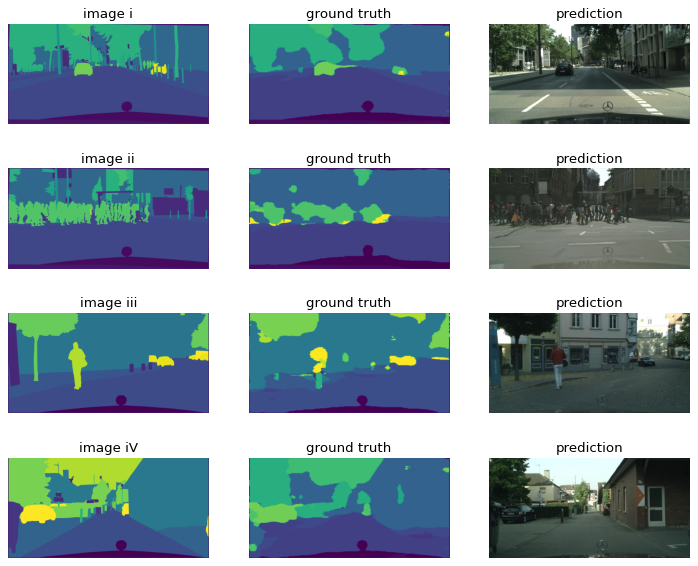

In [ ]:

im1a = './cityscapes/val/frankfurt_000000_015389_leftImg8bit.jpg'
im1b = './cityscapes/val/frankfurt_000000_015389_gtFine_labelIds.png'
im2a = './cityscapes/val/frankfurt_000001_057954_leftImg8bit.jpg'
im2b = './cityscapes/val/frankfurt_000001_057954_gtFine_labelIds.png'
im3a = './cityscapes/val/lindau_000037_000019_leftImg8bit.jpg'
im3b = './cityscapes/val/lindau_000037_000019_gtFine_labelIds.png'
im4a = './cityscapes/val/munster_000173_000019_leftImg8bit.jpg'
im4b = './cityscapes/val/munster_000173_000019_gtFine_labelIds.png'
show_image_subplot([Image.open(im1b), preds[im1a], Image.open(im1a),
                    Image.open(im2b), np.flip(preds[im2a], axis = 1), Image.open(im2a),
                    Image.open(im3b), preds[im3a], Image.open(im3a),
                    Image.open(im4b), preds[im4a], Image.open(im4a)],
                   4, 3, titles =
                    ["image i", "ground truth", "prediction",
                     "image ii", "ground truth", "prediction",
                     "image iii", "ground truth", "prediction",
                     "image iV", "ground truth", "prediction"],
                   size = (11, 9))